<a href="https://colab.research.google.com/github/Aymon05/Deep-learning-projects/blob/main/PhoneAddiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install libraries

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kagglehub

# Loading Dataset

In [ ]:
import os

# Login to Kaggle to authenticate
kagglehub.login()

# Download the latest version of the competition dataset
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

# List files in the downloaded path
print("Files:", os.listdir(path))

100%|██████████| 19.7M/19.7M [00:00<00:00, 148MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/playground-series-s6e8
Files: ['sample_submission.csv', 'train.csv', 'test.csv']


In [ ]:
Raw_df = pd.read_csv(path+'/train.csv')
test_df = pd.read_csv(path+ '/test.csv')
Raw_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [ ]:
test_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296297,987666,25.0,11.76,5.15,1.94,2.75,8.24,237.0,127.0,14.10,Male,NaN,NaN
296298,987667,28.0,7.67,2.70,1.55,2.95,5.54,187.0,121.0,8.25,Male,Low,Yes
296299,987668,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,987669,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes


Addicted label is our target.

# Exploratory Data Analysis


In [ ]:
Raw_df.info()

In [ ]:
test_df.info()

In [ ]:
Raw_df.describe()

In [ ]:
test_df.describe()

In [ ]:
sns.countplot(Raw_df,x='addicted_label')
plt.title('Addicted label counting in training set')

In [ ]:
px.histogram(Raw_df,x='age',color = 'addicted_label',
          title = 'Age vs Addicted level')

In [ ]:
px.histogram(Raw_df,x= 'daily_screen_time_hours',color = 'addicted_label',
             title = 'Distribution of screen time')
#Can be replaced with mean

In [ ]:
Raw_df['social_media_hours'].mode()

In [ ]:
px.histogram(Raw_df,x= 'social_media_hours',color = 'addicted_label',
             title = 'Distribution of media usage')
#Mean 2.47 does not represent unaddicted people. Replace null value with mode

In [ ]:
px.histogram(Raw_df,x= 'gaming_hours',color = 'addicted_label',
             title = 'Distribution of gaming hour')
#It is normal distribution . Can be replaced with mean

In [ ]:
px.histogram(Raw_df,x= 'sleep_hours',color = 'addicted_label',
             title = 'Distribution of sleep hour')

In [ ]:
px.histogram(Raw_df,x= 'notifications_per_day',color = 'addicted_label',
             title = 'Distribution of notification')

In [ ]:
Raw_df['work_study_hours'].mode()

In [ ]:
px.histogram(Raw_df,x='work_study_hours',color = 'addicted_label',
             title = 'Work study hour')
#replace nan with mode

In [ ]:
px.histogram(Raw_df,x= 'app_opens_per_day',color = 'addicted_label',
             title = 'Distribution of app open')

In [ ]:
px.histogram(Raw_df,x= 'weekend_screen_time',color = 'addicted_label',
             title = 'Distribution of weekend screen time')

In [ ]:
px.scatter(Raw_df[:10000],x='social_media_hours',y='gaming_hours',
           color = 'addicted_label',title = 'Social media vs Gaming time')

In [ ]:
px.scatter(Raw_df[:10000],x='work_study_hours',y='sleep_hours',
           color = 'addicted_label',title = 'Social media vs Gaming time')

In [ ]:
px.scatter(Raw_df[:10000],x='notifications_per_day',y='app_opens_per_day',
           color = 'addicted_label',title = 'Notification vs APp_open')

In [ ]:
px.scatter(Raw_df[:10000],x='weekend_screen_time',y='daily_screen_time_hours',
           color = 'addicted_label',title = 'Social media vs Gaming time')


In [ ]:
px.histogram(Raw_df[:10000],x = 'work_study_hours',y ='notifications_per_day',
           color = 'addicted_label',title = 'Study hour vs notification')

In [ ]:
px.histogram(Raw_df,x='gender',color = 'addicted_label',
             title = 'gender count')

In [ ]:
sns.histplot(test_df,x='gender')
plt.title('Gender count')

In [ ]:
px.histogram(Raw_df,x='stress_level',color = 'addicted_label',
             title = 'stress count')

In [ ]:
px.histogram(test_df,x='stress_level',
             title = 'stress count')

In [ ]:
px.histogram(Raw_df,x='academic_work_impact',color = 'addicted_label',
             title = 'Academic work impact')

In [ ]:
correlation = Raw_df.corr(numeric_only = True)
correlation

In [ ]:
sns.heatmap(correlation,annot = True,cmap = 'coolwarm')
plt.ticklabel_format


# Description
Age does not have impact on addicted label as we expected. Ther is label imbalance in Raw dataset. We have addicted people twice the amount of unaddicted people. As addicted people are twice the amount of non addicted people. So the distribution is totally unfair. Let's try **SMOTE** for balancing the data.


1.   Work study hours depicts the productive people who use device for productive purpose. So if screen time is high and work study hour is smaller so he must be addicted: Derived feature = recreation hour
2.   Figure out if gaming hour dominates screen time or social media hour.
Derived Feature : gaming ratio,social media ratio.
3.   Figure out time spended in app
4.   Daily screen time and weekend screen time have correlation of 0.8. Which can cause multiculinarity.


# Preprocess data
categorical columns

In [ ]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.utils import resample


In [ ]:
major_label = Raw_df[Raw_df['addicted_label'] == 1]
minor_label = Raw_df[Raw_df['addicted_label'] == 0]

In [ ]:
minor_label = resample(minor_label,replace = True,n_samples = len(major_label),
                  random_state = 42)

<Axes: xlabel='addicted_label', ylabel='count'>

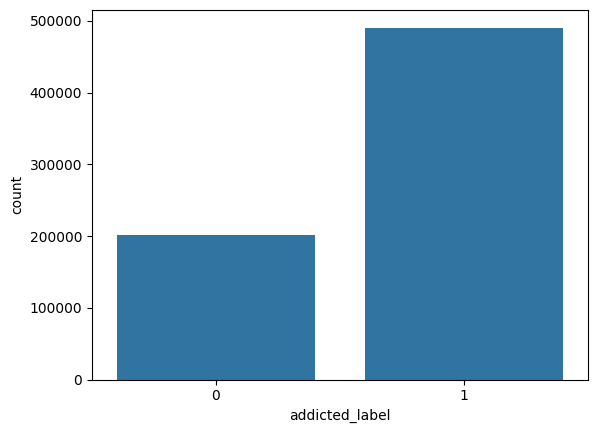

In [ ]:
sns.countplot(Raw_df,x = 'addicted_label')

In [ ]:
Raw_df = pd.concat([minor_label,major_label])

<Axes: xlabel='addicted_label', ylabel='count'>

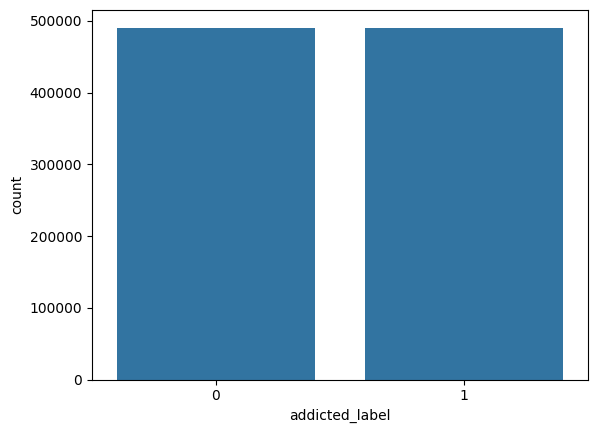

In [ ]:
sns.countplot(Raw_df,x = 'addicted_label')

In [ ]:
categorical_cols = Raw_df.select_dtypes(include = 'object').columns
categorical_cols

Index(['gender', 'stress_level', 'academic_work_impact'], dtype='object')

In [ ]:
def fill_cat_cols(df,*columns):
    for column in columns:
        df[column] = df[column].fillna('unknown')

In [ ]:
fill_cat_cols(Raw_df,categorical_cols)
Raw_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
419067,419067,21.0,4.70,0.80,1.03,2.24,5.98,216.0,68.0,NaN,Female,Low,Yes,0
504782,504782,32.0,7.76,2.06,NaN,1.25,6.17,NaN,151.0,NaN,Female,Low,Yes,0
453630,453630,33.0,4.52,0.80,0.56,2.92,6.25,242.0,124.0,6.14,Male,Medium,No,0
356592,356592,25.0,5.48,2.19,0.56,1.95,6.93,166.0,NaN,11.07,Male,High,Yes,0
411859,411859,20.0,3.45,1.02,1.20,0.99,6.84,80.0,19.0,5.31,Other,High,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691363,691363,23.0,NaN,1.96,NaN,2.78,8.48,150.0,82.0,NaN,Other,High,Yes,1
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,unknown,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1


In [ ]:
fill_cat_cols(test_df,categorical_cols)
Raw_df.isna().sum(),test_df.isna().sum()

(id                              0
 age                         40966
 daily_screen_time_hours    135898
 social_media_hours         190487
 gaming_hours               179792
 work_study_hours            73221
 sleep_hours                 62992
 notifications_per_day       95464
 app_opens_per_day          114053
 weekend_screen_time        158663
 gender                          0
 stress_level                    0
 academic_work_impact            0
 addicted_label                  0
 dtype: int64,
 id                             0
 age                        17138
 daily_screen_time_hours    32788
 social_media_hours         47397
 gaming_hours               59420
 work_study_hours           27777
 sleep_hours                22455
 notifications_per_day      34221
 app_opens_per_day          25705
 weekend_screen_time        50697
 gender                         0
 stress_level                   0
 academic_work_impact           0
 dtype: int64)

In [ ]:
test_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,unknown,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296297,987666,25.0,11.76,5.15,1.94,2.75,8.24,237.0,127.0,14.10,Male,unknown,unknown
296298,987667,28.0,7.67,2.70,1.55,2.95,5.54,187.0,121.0,8.25,Male,Low,Yes
296299,987668,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,987669,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes


In [ ]:
l_cols = ['stress_level','academic_work_impact']
for l_col in l_cols:
    l_encoder = LabelEncoder().fit(Raw_df[l_col])
    Raw_df[l_col] = l_encoder.transform(Raw_df[l_col])
    test_df[l_col] = l_encoder.transform(test_df[l_col])

Raw_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
419067,419067,21.0,4.70,0.80,1.03,2.24,5.98,216.0,68.0,NaN,Female,1,1,0
504782,504782,32.0,7.76,2.06,NaN,1.25,6.17,NaN,151.0,NaN,Female,1,1,0
453630,453630,33.0,4.52,0.80,0.56,2.92,6.25,242.0,124.0,6.14,Male,2,0,0
356592,356592,25.0,5.48,2.19,0.56,1.95,6.93,166.0,NaN,11.07,Male,0,1,0
411859,411859,20.0,3.45,1.02,1.20,0.99,6.84,80.0,19.0,5.31,Other,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691363,691363,23.0,NaN,1.96,NaN,2.78,8.48,150.0,82.0,NaN,Other,0,1,1
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,3,0,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,0,0,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,2,0,1


In [ ]:
oh_encoder = OneHotEncoder(sparse_output = False,handle_unknown = 'ignore')
oh_encoder.fit(Raw_df[['gender']])

category = oh_encoder.get_feature_names_out()
category

array(['gender_Female', 'gender_Male', 'gender_Other', 'gender_unknown'],
      dtype=object)

In [ ]:
Raw_df[category] = oh_encoder.transform(Raw_df[['gender']])
test_df[category] = oh_encoder.transform(test_df[['gender']])
Raw_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,gender_Female,gender_Male,gender_Other,gender_unknown
419067,419067,21.0,4.70,0.80,1.03,2.24,5.98,216.0,68.0,NaN,Female,1,1,0,1.0,0.0,0.0,0.0
504782,504782,32.0,7.76,2.06,NaN,1.25,6.17,NaN,151.0,NaN,Female,1,1,0,1.0,0.0,0.0,0.0
453630,453630,33.0,4.52,0.80,0.56,2.92,6.25,242.0,124.0,6.14,Male,2,0,0,0.0,1.0,0.0,0.0
356592,356592,25.0,5.48,2.19,0.56,1.95,6.93,166.0,NaN,11.07,Male,0,1,0,0.0,1.0,0.0,0.0
411859,411859,20.0,3.45,1.02,1.20,0.99,6.84,80.0,19.0,5.31,Other,0,0,0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691363,691363,23.0,NaN,1.96,NaN,2.78,8.48,150.0,82.0,NaN,Other,0,1,1,0.0,0.0,1.0,0.0
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,3,0,1,0.0,1.0,0.0,0.0
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,0,0,1,1.0,0.0,0.0,0.0
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,2,0,1,0.0,0.0,1.0,0.0


Fill numeric values

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
mean_imputer = SimpleImputer(strategy = 'mean')
mode_imputer = SimpleImputer(strategy = 'most_frequent')

In [ ]:
mean_cols = ['age','daily_screen_time_hours','gaming_hours','sleep_hours',
             'notifications_per_day','app_opens_per_day','weekend_screen_time']
mode_cols = ['social_media_hours','work_study_hours']

In [ ]:
mean_imputer.fit(Raw_df[mean_cols])
mode_imputer.fit(Raw_df[mode_cols])

SimpleImputer(strategy='most_frequent')

In [ ]:
Raw_df[mean_cols] = mean_imputer.transform(Raw_df[mean_cols])
test_df[mean_cols] = mean_imputer.transform(test_df[mean_cols])
Raw_df[mode_cols] = mode_imputer.transform(Raw_df[mode_cols])
test_df[mode_cols] = mode_imputer.transform(test_df[mode_cols])
Raw_df.isna().sum(),test_df.isna().sum()

(id                         0
 age                        0
 daily_screen_time_hours    0
 social_media_hours         0
 gaming_hours               0
 work_study_hours           0
 sleep_hours                0
 notifications_per_day      0
 app_opens_per_day          0
 weekend_screen_time        0
 gender                     0
 stress_level               0
 academic_work_impact       0
 addicted_label             0
 gender_Female              0
 gender_Male                0
 gender_Other               0
 gender_unknown             0
 dtype: int64,
 id                         0
 age                        0
 daily_screen_time_hours    0
 social_media_hours         0
 gaming_hours               0
 work_study_hours           0
 sleep_hours                0
 notifications_per_day      0
 app_opens_per_day          0
 weekend_screen_time        0
 gender                     0
 stress_level               0
 academic_work_impact       0
 gender_Female              0
 gender_Male             

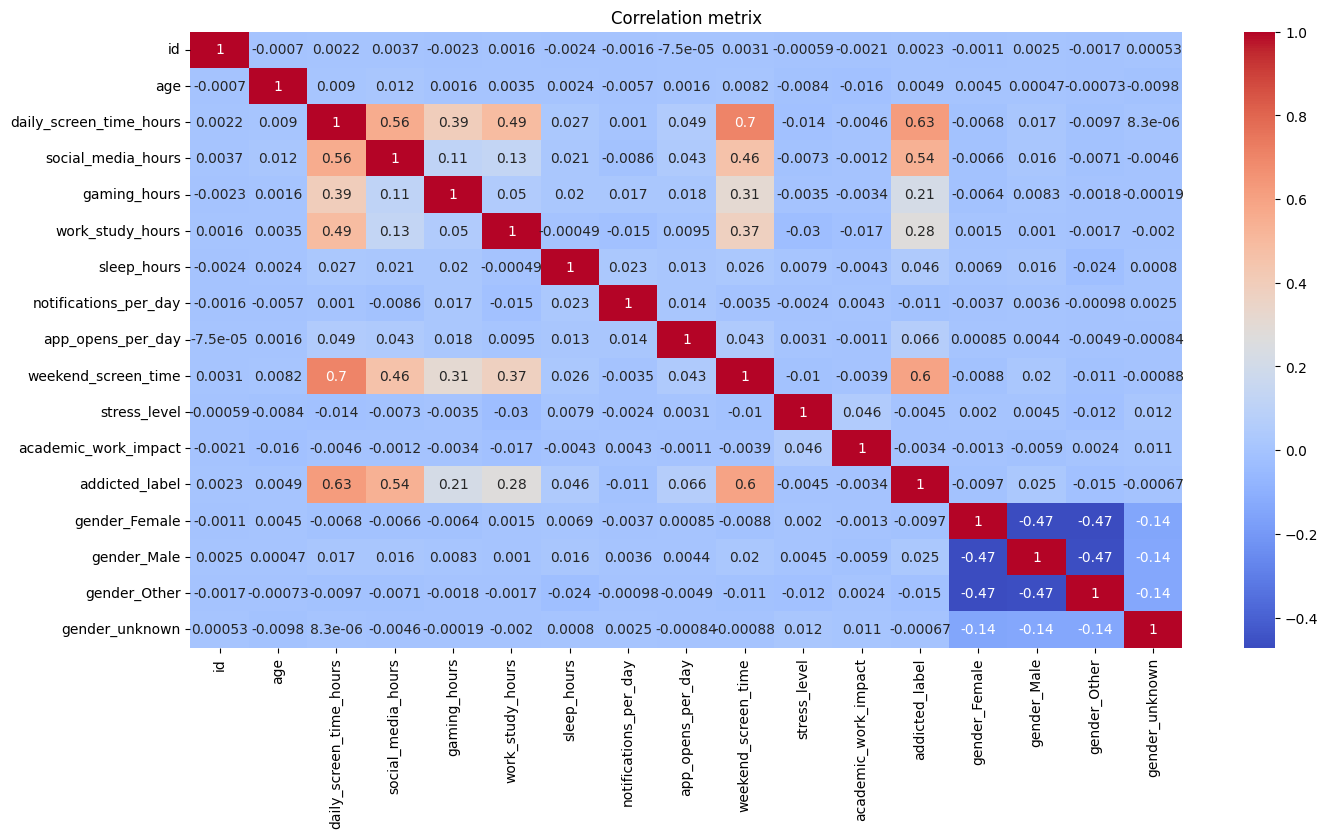

In [ ]:
plt.figure(figsize = (16,8))
sns.heatmap(Raw_df.corr(numeric_only = True),annot = True,cmap = 'coolwarm')
plt.ticklabel_format
plt.title('Correlation metrix')
plt.show()

# Feature Engineering:
Let's try feature engineering with work study hour . We will find recreation hour and others as well


*   recreation hour = screen time - work study hour
*   gaming ratio = gaming hour / screen time
*   media usage ratio = social media hour / screen time
*   app time = screen time / app open per day
*   **Drop** gender and id



In [ ]:
def add_features(df):
    df['recreation_hour'] = df['daily_screen_time_hours'] - df['work_study_hours']
    df['gaming_ratio'] = df['gaming_hours'] / df['daily_screen_time_hours']
    df['media usage ratio'] = df['social_media_hours'] / df['daily_screen_time_hours']
    df['app_time'] = df['daily_screen_time_hours'] / df['app_opens_per_day']
    # include
    df = df.drop(columns = ['id','gender'])
    return df

In [ ]:
Raw_df = add_features(Raw_df)
Raw_df

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
419067,21.00000,4.70000,0.80,1.030000,2.24,5.98,216.000000,68.000000,8.700869,1,1,0,1.0,0.0,0.0,0.0,2.46000,0.219149,0.170213,0.069118
504782,32.00000,7.76000,2.06,1.369999,1.25,6.17,146.191237,151.000000,8.700869,1,1,0,1.0,0.0,0.0,0.0,6.51000,0.176546,0.265464,0.051391
453630,33.00000,4.52000,0.80,0.560000,2.92,6.25,242.000000,124.000000,6.140000,2,0,0,0.0,1.0,0.0,0.0,1.60000,0.123894,0.176991,0.036452
356592,25.00000,5.48000,2.19,0.560000,1.95,6.93,166.000000,101.209979,11.070000,0,1,0,0.0,1.0,0.0,0.0,3.53000,0.102190,0.399635,0.054145
411859,20.00000,3.45000,1.02,1.200000,0.99,6.84,80.000000,19.000000,5.310000,0,0,0,0.0,0.0,1.0,0.0,2.46000,0.347826,0.295652,0.181579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691363,23.00000,6.87294,1.96,1.369999,2.78,8.48,150.000000,82.000000,8.700869,0,1,1,0.0,0.0,1.0,0.0,4.09294,0.199332,0.285176,0.083816
691364,22.00000,10.78000,3.25,1.570000,1.65,7.71,86.000000,94.000000,12.890000,3,0,1,0.0,1.0,0.0,0.0,9.13000,0.145640,0.301484,0.114681
691365,20.00000,3.45000,1.86,0.890000,0.30,6.59,221.000000,42.000000,8.470000,0,0,1,1.0,0.0,0.0,0.0,3.15000,0.257971,0.539130,0.082143
691366,26.60277,6.87294,1.68,1.369999,2.06,6.16,146.191237,86.000000,7.790000,2,0,1,0.0,0.0,1.0,0.0,4.81294,0.199332,0.244437,0.079918


In [ ]:
test_df = add_features(test_df)
test_df

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
0,30.00000,9.34000,1.68,0.770000,4.09,7.150000,153.0,16.0,8.700869,2,1,0.0,0.0,1.0,0.0,5.25000,0.082441,0.179872,0.583750
1,26.60277,6.87294,1.91,1.369999,1.20,8.670000,239.0,148.0,10.680000,0,0,1.0,0.0,0.0,0.0,5.67294,0.199332,0.277901,0.046439
2,26.00000,8.48000,3.64,1.369999,3.39,7.470000,106.0,123.0,8.700869,3,0,0.0,1.0,0.0,0.0,5.09000,0.161557,0.429245,0.068943
3,20.00000,8.37000,2.99,1.690000,2.53,5.450000,178.0,55.0,9.880000,0,1,0.0,1.0,0.0,0.0,5.84000,0.201912,0.357228,0.152182
4,25.00000,8.25000,4.02,1.210000,2.32,8.460000,63.0,86.0,10.720000,1,0,0.0,1.0,0.0,0.0,5.93000,0.146667,0.487273,0.095930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296297,25.00000,11.76000,5.15,1.940000,2.75,8.240000,237.0,127.0,14.100000,3,2,0.0,1.0,0.0,0.0,9.01000,0.164966,0.437925,0.092598
296298,28.00000,7.67000,2.70,1.550000,2.95,5.540000,187.0,121.0,8.250000,1,1,0.0,1.0,0.0,0.0,4.72000,0.202086,0.352021,0.063388
296299,33.00000,5.27000,1.84,0.200000,2.44,8.290000,96.0,73.0,6.570000,0,0,1.0,0.0,0.0,0.0,2.83000,0.037951,0.349146,0.072192
296300,26.60277,6.87294,1.25,0.520000,0.71,6.270000,57.0,38.0,7.190000,1,1,1.0,0.0,0.0,0.0,6.16294,0.075659,0.181873,0.180867


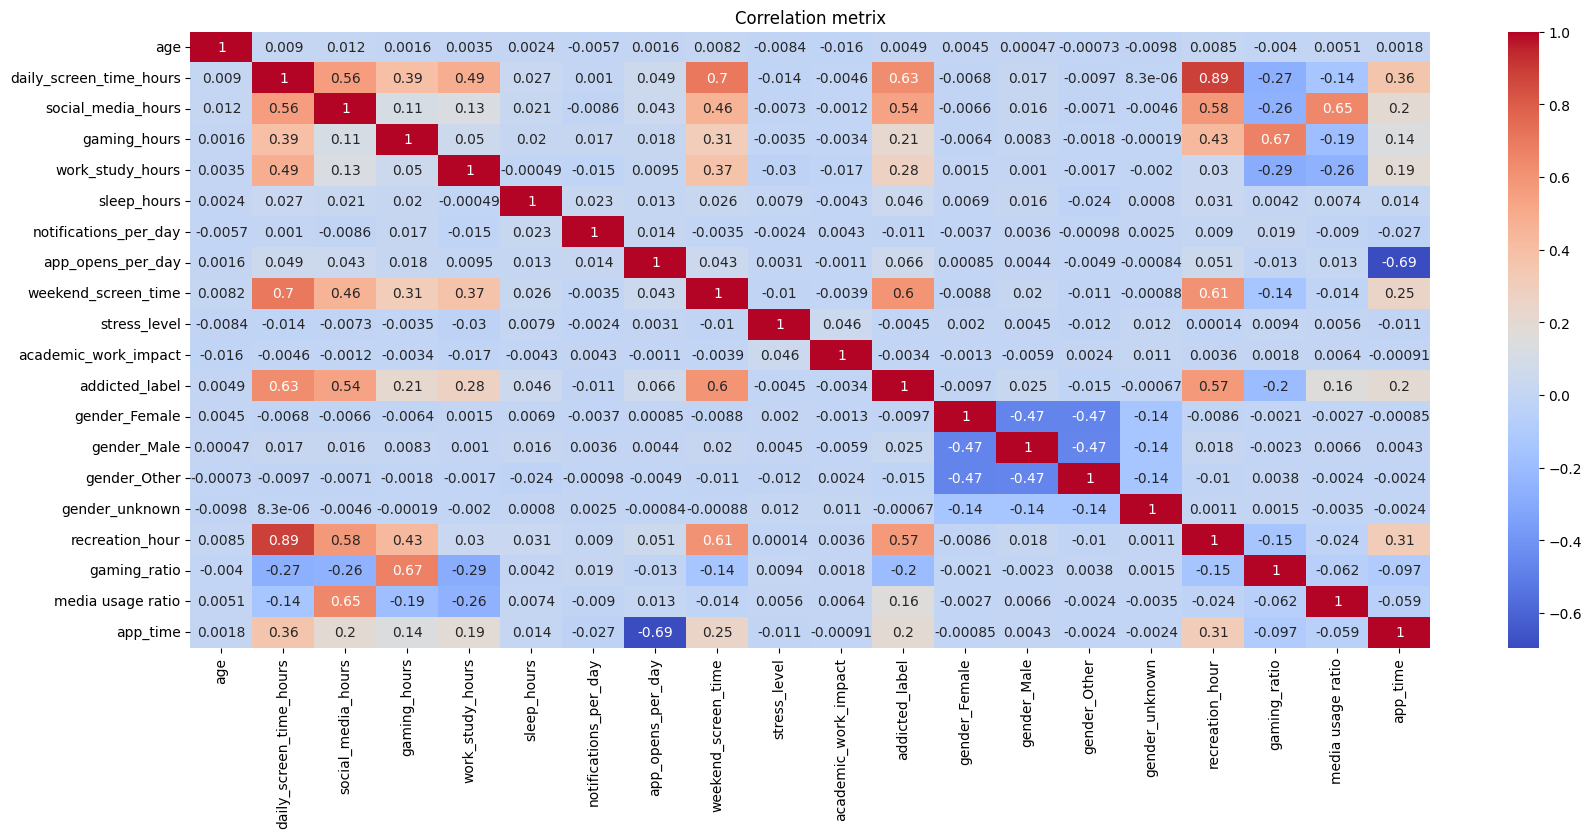

In [ ]:
plt.figure(figsize = (20,8))
sns.heatmap(Raw_df.corr(numeric_only = True),annot = True,cmap = 'coolwarm')
plt.ticklabel_format
plt.title('Correlation metrix')
plt.show()

# Scale numeric features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
numeric_cols = ['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'recreation_hour',
 'gaming_ratio',
 'media usage ratio',
 'app_time']

In [ ]:
scaler = MinMaxScaler()
scaler.fit(Raw_df[numeric_cols])


MinMaxScaler()

In [ ]:
Raw_df[numeric_cols] = scaler.transform(Raw_df[numeric_cols])
Raw_df

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
419067,0.176471,0.289655,0.10000,0.2575,0.373333,0.328889,0.852174,0.321212,0.480403,1,1,0,1.0,0.0,0.0,0.0,0.231126,0.079981,0.050659,0.072723
504782,0.823529,0.500690,0.25750,0.3425,0.208333,0.371111,0.548658,0.824242,0.480403,1,1,0,1.0,0.0,0.0,0.0,0.499338,0.064433,0.079007,0.053291
453630,0.882353,0.277241,0.10000,0.1400,0.486667,0.388889,0.965217,0.660606,0.330205,2,0,0,0.0,1.0,0.0,0.0,0.174172,0.045217,0.052676,0.036914
356592,0.411765,0.343448,0.27375,0.1400,0.325000,0.540000,0.634783,0.522485,0.619355,0,1,0,0.0,1.0,0.0,0.0,0.301987,0.037296,0.118939,0.056310
411859,0.117647,0.203448,0.12750,0.3000,0.165000,0.520000,0.260870,0.024242,0.281525,0,0,0,0.0,0.0,1.0,0.0,0.231126,0.126944,0.087992,0.196006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691363,0.294118,0.439513,0.24500,0.3425,0.463333,0.884444,0.565217,0.406061,0.480403,0,1,1,0.0,0.0,1.0,0.0,0.339268,0.072749,0.084874,0.088836
691364,0.235294,0.708966,0.40625,0.3925,0.275000,0.713333,0.286957,0.478788,0.726100,3,0,1,0.0,1.0,0.0,0.0,0.672848,0.053153,0.089727,0.122671
691365,0.117647,0.203448,0.23250,0.2225,0.050000,0.464444,0.873913,0.163636,0.466862,0,0,1,1.0,0.0,0.0,0.0,0.276821,0.094150,0.160455,0.087002
691366,0.506045,0.439513,0.21000,0.3425,0.343333,0.368889,0.548658,0.430303,0.426979,2,0,1,0.0,0.0,1.0,0.0,0.386950,0.072749,0.072749,0.084563


In [ ]:
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])
test_df

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
0,0.705882,0.609655,0.21000,0.1925,0.681667,0.588889,0.578261,0.006061,0.480403,2,1,0.0,0.0,1.0,0.0,0.415894,0.030088,0.053533,0.636876
1,0.506045,0.439513,0.23875,0.3425,0.200000,0.926667,0.952174,0.806061,0.596481,0,0,1.0,0.0,0.0,0.0,0.443903,0.072749,0.082709,0.047862
2,0.470588,0.550345,0.45500,0.3425,0.565000,0.660000,0.373913,0.654545,0.480403,3,0,0.0,1.0,0.0,0.0,0.405298,0.058962,0.127752,0.072532
3,0.117647,0.542759,0.37375,0.4225,0.421667,0.211111,0.686957,0.242424,0.549560,0,1,0.0,1.0,0.0,0.0,0.454967,0.073690,0.106318,0.163780
4,0.411765,0.534483,0.50250,0.3025,0.386667,0.880000,0.186957,0.430303,0.598827,1,0,0.0,1.0,0.0,0.0,0.460927,0.053528,0.145022,0.102116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296297,0.411765,0.776552,0.64375,0.4850,0.458333,0.831111,0.943478,0.678788,0.797067,3,2,0.0,1.0,0.0,0.0,0.664901,0.060207,0.130335,0.098464
296298,0.588235,0.494483,0.33750,0.3875,0.491667,0.231111,0.726087,0.642424,0.453959,1,1,0.0,1.0,0.0,0.0,0.380795,0.073754,0.104768,0.066443
296299,0.882353,0.328966,0.23000,0.0500,0.406667,0.842222,0.330435,0.351515,0.355425,0,0,1.0,0.0,0.0,0.0,0.255629,0.013851,0.103913,0.076093
296300,0.506045,0.439513,0.15625,0.1300,0.118333,0.393333,0.160870,0.139394,0.391789,1,1,1.0,0.0,0.0,0.0,0.476354,0.027613,0.054129,0.195226


# Split training and validation dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
def select_cols(columns):
    get_col = list()
    for column in columns:
        if column == 'addicted_label':
            continue
        else:
            get_col.append(column)
    return get_col



In [ ]:
input_cols = select_cols(Raw_df.columns)
target_col = 'addicted_label'
input_cols

['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'gender_unknown',
 'recreation_hour',
 'gaming_ratio',
 'media usage ratio',
 'app_time']

In [ ]:
x_inputs = Raw_df[input_cols]
x_target = Raw_df[target_col]
x_inputs

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
419067,0.176471,0.289655,0.10000,0.2575,0.373333,0.328889,0.852174,0.321212,0.480403,1,1,1.0,0.0,0.0,0.0,0.231126,0.079981,0.050659,0.072723
504782,0.823529,0.500690,0.25750,0.3425,0.208333,0.371111,0.548658,0.824242,0.480403,1,1,1.0,0.0,0.0,0.0,0.499338,0.064433,0.079007,0.053291
453630,0.882353,0.277241,0.10000,0.1400,0.486667,0.388889,0.965217,0.660606,0.330205,2,0,0.0,1.0,0.0,0.0,0.174172,0.045217,0.052676,0.036914
356592,0.411765,0.343448,0.27375,0.1400,0.325000,0.540000,0.634783,0.522485,0.619355,0,1,0.0,1.0,0.0,0.0,0.301987,0.037296,0.118939,0.056310
411859,0.117647,0.203448,0.12750,0.3000,0.165000,0.520000,0.260870,0.024242,0.281525,0,0,0.0,0.0,1.0,0.0,0.231126,0.126944,0.087992,0.196006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691363,0.294118,0.439513,0.24500,0.3425,0.463333,0.884444,0.565217,0.406061,0.480403,0,1,0.0,0.0,1.0,0.0,0.339268,0.072749,0.084874,0.088836
691364,0.235294,0.708966,0.40625,0.3925,0.275000,0.713333,0.286957,0.478788,0.726100,3,0,0.0,1.0,0.0,0.0,0.672848,0.053153,0.089727,0.122671
691365,0.117647,0.203448,0.23250,0.2225,0.050000,0.464444,0.873913,0.163636,0.466862,0,0,1.0,0.0,0.0,0.0,0.276821,0.094150,0.160455,0.087002
691366,0.506045,0.439513,0.21000,0.3425,0.343333,0.368889,0.548658,0.430303,0.426979,2,0,0.0,0.0,1.0,0.0,0.386950,0.072749,0.072749,0.084563


In [ ]:
train_inputs,val_inputs,train_target,val_target = train_test_split(x_inputs,   x_target,test_size=0.25,random_state = 42)
train_inputs

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
333558,0.176471,0.351034,0.21000,0.3425,0.080000,0.506582,0.839130,0.896970,0.384164,3,0,0.0,0.0,1.0,0.0,0.406623,0.089445,0.089445,0.034549
351284,0.882353,0.250345,0.03375,0.3425,0.208333,0.580000,0.260870,0.987879,0.248680,2,1,0.0,1.0,0.0,0.0,0.258940,0.121065,0.019457,0.022390
471582,0.000000,0.279310,0.10000,0.2275,0.398333,0.706667,0.682609,0.606061,0.303226,1,1,0.0,0.0,1.0,0.0,0.211258,0.072993,0.052329,0.040327
660091,0.294118,0.544828,0.21000,0.5775,0.405000,0.506582,0.039130,0.927273,0.480403,3,0,0.0,0.0,1.0,0.0,0.463576,0.100365,0.059524,0.051766
437669,0.823529,0.484828,0.21000,0.3850,0.668333,0.088889,0.430435,0.522485,0.667449,0,0,0.0,1.0,0.0,0.0,0.301325,0.074641,0.066401,0.078514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406813,0.470588,0.218621,0.12250,0.3675,0.143333,0.715556,0.673913,0.000000,0.321408,0,0,0.0,0.0,1.0,0.0,0.254305,0.146184,0.079473,0.265164
7760,0.117647,0.222759,0.05500,0.3300,0.276667,0.531111,0.691304,0.522485,0.407625,2,0,0.0,0.0,1.0,0.0,0.205298,0.129156,0.035108,0.037355
121244,0.294118,0.299310,0.11500,0.2125,0.405000,0.117778,0.534783,0.418182,0.232845,2,0,0.0,0.0,1.0,0.0,0.227815,0.064095,0.056572,0.060118
254812,0.882353,0.615172,0.45750,0.1300,0.745000,0.506582,0.265217,0.260606,0.647507,2,2,1.0,0.0,0.0,0.0,0.396026,0.020147,0.115635,0.174997


In [ ]:
val_inputs

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other,gender_unknown,recreation_hour,gaming_ratio,media usage ratio,app_time
170391,0.764706,0.222069,0.09500,0.3900,0.160000,0.853333,0.548658,0.648485,0.374194,0,0,0.0,1.0,0.0,0.0,0.250993,0.153049,0.060804,0.030381
139471,0.235294,0.740690,0.53000,0.3225,0.845000,0.048889,0.147826,0.824242,0.620528,0,1,0.0,0.0,1.0,0.0,0.476821,0.041886,0.112269,0.078555
450102,0.882353,0.308966,0.25750,0.0350,0.346667,0.888889,0.756522,0.678788,0.578886,0,0,0.0,1.0,0.0,0.0,0.260265,0.010260,0.123111,0.039941
406845,0.764706,0.439513,0.54750,0.5700,0.195000,0.251111,0.839130,0.666667,0.577126,3,0,0.0,1.0,0.0,0.0,0.445890,0.121072,0.189667,0.057229
211992,1.000000,0.500000,0.29000,0.5075,0.453333,0.864444,0.791304,0.387879,0.434604,0,0,0.0,0.0,1.0,0.0,0.401325,0.095597,0.089094,0.104496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534985,0.941176,0.605517,0.56875,0.5175,0.218333,0.506667,0.113043,0.048485,0.713783,1,0,0.0,0.0,1.0,0.0,0.596026,0.081409,0.145923,0.439258
414071,0.058824,0.746897,0.42875,0.5850,0.485000,0.388889,0.900000,0.800000,0.686804,2,1,0.0,0.0,1.0,0.0,0.625828,0.075376,0.090100,0.081446
216926,0.506045,0.332414,0.21000,0.1175,0.573333,0.388889,0.656522,0.393939,0.297361,0,1,1.0,0.0,0.0,0.0,0.192715,0.032243,0.093985,0.069854
434622,0.411765,0.250345,0.21000,0.3425,0.216667,0.268889,0.126087,0.812121,0.233431,3,1,1.0,0.0,0.0,0.0,0.255629,0.121065,0.121065,0.027340


# Function to submit prediction

In [ ]:
sample_submission = pd.read_csv(path + '/sample_submission.csv')
sample_submission

,id,addicted_label
0,691369,0.709424
1,691370,0.709424
2,691371,0.709424
3,691372,0.709424
4,691373,0.709424
...,...,...
296297,987666,0.709424
296298,987667,0.709424
296299,987668,0.709424
296300,987669,0.709424


In [ ]:
def submit(model,test_df,name):
    sample_submission = pd.read_csv(path + '/sample_submission.csv')
    test_pred = model.predict(test_df)
    sample_submission['addicted_label'] = test_pred
    sample_submission.to_csv(name,index = None)
    return sample_submission


## Train models:
Function for HyperParametre Tuning

*   LogisticRegression
*   DecisionTreeClassifier
*   RandomForestClassifier
*   XGBoostClassifier
   



In [ ]:
from sklearn.metrics import accuracy_score
def train_evaluate(Model,**params):
    model = Model(**params).fit(train_inputs,train_target)
    train_score = accuracy_score(model.predict(train_inputs),train_target)
    val_score = accuracy_score(model.predict(val_inputs),val_target)
    return train_score,val_score

def plot_param(Model,param_name,param_values,**other_params):
    train_scores,val_scores = list(),list()
    for value in param_values:
        params = dict(other_params)
        params[param_name] = value
        train_score,val_score = train_evaluate(Model,**params)
        train_scores.append(train_score)
        val_scores.append(val_score)
    plt.figure(figsize = (10,7))
    plt.plot(param_values,train_scores,label = 'Train score',marker = 'o')
    plt.plot(param_values,val_scores,label = 'Validation score',marker = 'o')
    plt.legend()
    plt.title(param_name)
    plt.show()



# Linear models
1.  **LogisticRegression**
2.  **RidgeClassifier**

In [ ]:
from sklearn.linear_model import LogisticRegression
LR_model = LogisticRegression(random_state = 42)

In [ ]:
LR_model.fit(train_inputs,train_target)

In [ ]:
LR_model.score(train_inputs,train_target)

In [ ]:
LR_model.score(val_inputs,val_target)

In [ ]:
submit(LR_model,test_df,'LR_model1.csv')

In [ ]:
best_param = {
    'random_state' : 42
}

In [ ]:
# Train it again with Hyper Parametre
plot_param(LogisticRegression,'max_iter',[100,200,300,400,500,1000],**best_param)

In [ ]:
# Let's try RidgeClassifier
from sklearn.linear_model import RidgeClassifier

In [ ]:
plot_param(RidgeClassifier,'max_iter',[100,300,500,800,1000],**best_param)

# Try out tree based models
* DecissionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
plot_param(DecisionTreeClassifier,'max_depth',[3,5,7,10,15,18,21],**best_param)

In [ ]:
best_param['max_depth'] = 7

In [ ]:
plot_param(DecisionTreeClassifier,'max_features',[4,6,8,10,12,14,18,20],**best_param)

In [ ]:
best_param['max_features'] = 10

In [ ]:
plot_param(DecisionTreeClassifier,'max_leaf_nodes',[5,8,11,14,17,20,23],**best_param)

In [ ]:
best_param['max_leaf_nodes'] = 23

In [ ]:
plot_param(DecisionTreeClassifier,'max_leaf_nodes',[5,8,11,14,17,20,23],**best_param)

In [ ]:
Dtree_model = DecisionTreeClassifier(**best_param).fit(train_inputs,train_target)

In [ ]:
#Submit
submit(Dtree_model,test_df,'DecisionTreeModel.csv')

# Ensemble Learning:
*  RandomForestClassifier
*  XGBClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# reinitialize best param
best_param = {
    'random_state' : 42,
    'n_jobs' : -1,
    'n_estimators' : 100,
    'max_depth' : 12,
    'max_samples' : 25

}

In [ ]:
plot_param(RandomForestClassifier,'n_estimators',[25,50,100,200,500,1000],**best_param)

In [ ]:
plot_param(RandomForestClassifier,'max_depth',[4,8,12,16,20,24],**best_param)

In [ ]:
plot_param(RandomForestClassifier,'max_samples',[5,10,15,20,25,30,35,40,45,50,100],**best_param)

In [ ]:
plot_param(RandomForestClassifier,'max_leaf_nodes',[55,60,65,70,75,80,85,90,95],**best_param)

In [ ]:

Rdf_model = RandomForestClassifier(**best_param)

In [ ]:
Rdf_model.fit(train_inputs,train_target)

In [ ]:
submit(Rdf_model,test_df,'RandomForest2.csv')

# Try boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
best_param = {
    'random_state' : 42
}

In [ ]:
plot_param(GradientBoostingClassifier,'n_estimators',[400,500,600],**best_param)

In [ ]:
GBC_model = GradientBoostingClassifier(random_state = 42,n_estimators = 1000)
GBC_model.fit(train_inputs,train_target)

In [ ]:
from sklearn.model_selection import GridSearchCV
t_model = GridSearchCV(GradientBoostingClassifier(),
                       {
                           'random_state':[42],
                           'n_estimators' : [1000],
                           'learning_rate': [0.001,0.01,0.1,0.2],
                           'max_depth': [2,3,4,5,6,8,10]
                       },cv = 5,n_jobs = -1)

In [ ]:
t_model.fit(train_inputs,train_target)

In [ ]:
submit(GBC_model,test_df,'GradientBoostingClassifier1.csv')

# Try Deep learning with tensorflow

In [ ]:
import tensorflow as tf

In [ ]:
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation = 'relu'),
    tf.keras.layers.Dense(100,activation = 'relu'),
    tf.keras.layers.Dense(50,activation = 'relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
tf_model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics = ['accuracy'])
schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: lr * tf.math.exp(-0.1))
history = tf_model.fit(train_inputs,train_target,epochs = 5,
             validation_data = (val_inputs,val_target),
            callbacks = [schedule])

ValueError: The output of the `schedule` function should be a float. Got: 0.0009048373904079199

<Axes: >

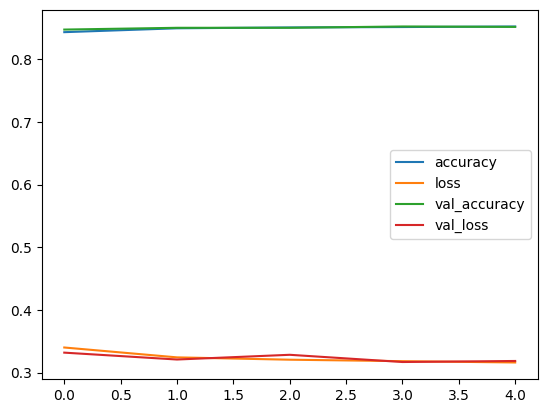

In [ ]:
pd.DataFrame(history.history).plot()